# 🕌 Pencarian Ayat Al-Quran — Vector Space Model (Multi-Bahasa)
**Metode:** TF-IDF + Cosine Similarity  
**Bahasa:** Indonesia 🇮🇩 & English 🇬🇧  
**Dataset:** Kementerian Agama RI + Sahih International

## 📦 1. Import Library

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

## 📂 2. Load & Parsing Dataset (Multi-Bahasa dari Awal)

In [4]:
# ─── Konfigurasi file per bahasa ───────────────────────────────────────────
# Tambahkan bahasa baru cukup di sini, tanpa ubah kode lain
LANGUAGE_FILES = {
    'Indonesia': '../resource/id.indonesian.txt',
    'English'  : '../resource/en.sahih.txt',
    # 'French' : 'fr_hamidullah.txt',  # ← contoh menambah bahasa baru
}

def load_quran(filepath):
    """Baca file terjemahan Quran format surah|ayat|teks."""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split('|', 2)
            if len(parts) == 3:
                surah, ayat, teks = parts
                data.append({'surah': int(surah), 'ayat': int(ayat), 'teks': teks.strip()})
    return pd.DataFrame(data)

def preprocess(text):
    """Bersihkan teks: lowercase, hapus non-huruf, rapikan spasi."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ─── Load semua bahasa sekaligus ────────────────────────────────────────────
corpus = {}   # { 'Indonesia': DataFrame, 'English': DataFrame, ... }
models = {}   # { 'Indonesia': {'vectorizer': ..., 'matrix': ...}, ... }

for lang, filepath in LANGUAGE_FILES.items():
    print(f"⏳ Memuat [{lang}] dari '{filepath}'...")
    df_lang = load_quran(filepath)
    df_lang['teks_bersih'] = df_lang['teks'].apply(preprocess)

    vectorizer = TfidfVectorizer(min_df=2, max_df=0.95, sublinear_tf=True)
    matrix = vectorizer.fit_transform(df_lang['teks_bersih'])

    corpus[lang] = df_lang
    models[lang] = {'vectorizer': vectorizer, 'matrix': matrix}

    print(f"   ✅ {len(df_lang):,} ayat | {len(vectorizer.vocabulary_):,} kosakata unik")

print(f"\n🎉 Semua bahasa berhasil dimuat: {list(corpus.keys())}")

⏳ Memuat [Indonesia] dari '../resource/id.indonesian.txt'...
   ✅ 6,236 ayat | 3,985 kosakata unik
⏳ Memuat [English] dari '../resource/en.sahih.txt'...
   ✅ 6,236 ayat | 3,355 kosakata unik

🎉 Semua bahasa berhasil dimuat: ['Indonesia', 'English']


## 🔎 3. Fungsi Pencarian Multi-Bahasa

In [5]:
def cari_ayat(query, lang='Indonesia', top_n=5, filter_surah=None):
    """
    Cari ayat paling relevan menggunakan TF-IDF + Cosine Similarity.

    Parameters
    ----------
    query        : str  — kalimat pencarian
    lang         : str  — bahasa terjemahan ('Indonesia' / 'English')
    top_n        : int  — jumlah hasil teratas
    filter_surah : int  — batasi pencarian ke 1 surah (opsional)

    Returns
    -------
    pd.DataFrame dengan kolom: surah, ayat, teks, similarity
    """
    if lang not in corpus:
        raise ValueError(f"Bahasa '{lang}' tidak tersedia. Pilih: {list(corpus.keys())}")

    df_lang   = corpus[lang]
    vectorizer = models[lang]['vectorizer']
    matrix    = models[lang]['matrix']

    # 1. Preprocess & vectorize query
    query_vec = vectorizer.transform([preprocess(query)])

    # 2. Filter surah jika diperlukan
    if filter_surah:
        idx = df_lang[df_lang['surah'] == filter_surah].index.tolist()
        target_matrix = matrix[idx]
        target_df = df_lang.loc[idx].reset_index(drop=True)
    else:
        target_matrix = matrix
        target_df = df_lang.reset_index(drop=True)

    # 3. Hitung cosine similarity
    skor = cosine_similarity(query_vec, target_matrix)[0]

    # 4. Ambil Top-N, buang skor 0
    top_idx = np.argsort(skor)[::-1][:top_n]
    hasil = target_df.iloc[top_idx][['surah', 'ayat', 'teks']].copy()
    hasil['similarity'] = skor[top_idx].round(4)
    hasil = hasil[hasil['similarity'] > 0].reset_index(drop=True)
    hasil.index += 1
    return hasil


def tampilkan_hasil(query, lang='Indonesia', top_n=5, filter_surah=None):
    """Cetak hasil pencarian dengan format rapi."""
    flag = {'Indonesia': '🇮🇩', 'English': '🇬🇧'}.get(lang, '🌐')
    print(f"{'='*68}")
    print(f"  {flag} Bahasa : {lang}")
    print(f"  🔍 Query  : '{query}'")
    if filter_surah:
        print(f"  📌 Filter : Surah {filter_surah}")
    print(f"{'='*68}")

    hasil = cari_ayat(query, lang=lang, top_n=top_n, filter_surah=filter_surah)

    if hasil.empty:
        print("  ❌ Tidak ditemukan ayat yang relevan.")
    else:
        for i, row in hasil.iterrows():
            print(f"\n  [{i}] Q{row['surah']}:A{row['ayat']}  |  Similarity: {row['similarity']:.4f}")
            print(f"      {row['teks']}")
    print(f"{'='*68}\n")
    return hasil

## 🧪 4. Demo — Bahasa Indonesia 🇮🇩

In [6]:
tampilkan_hasil("dirikanlah shalat dan tunaikanlah zakat", lang='Indonesia', top_n=5)

  🇮🇩 Bahasa : Indonesia
  🔍 Query  : 'dirikanlah shalat dan tunaikanlah zakat'

  [1] Q2:A43  |  Similarity: 0.6555
      Dan dirikanlah shalat, tunaikanlah zakat dan ruku'lah beserta orang-orang yang ruku'.

  [2] Q24:A56  |  Similarity: 0.6018
      Dan dirikanlah sembahyang, tunaikanlah zakat, dan taatlah kepada rasul, supaya kamu diberi rahmat.

  [3] Q108:A2  |  Similarity: 0.5691
      Maka dirikanlah shalat karena Tuhanmu; dan berkorbanlah.

  [4] Q2:A110  |  Similarity: 0.5538
      Dan dirikanlah shalat dan tunaikanlah zakat. Dan kebaikan apa saja yang kamu usahakan bagi dirimu, tentu kamu akan mendapat pahala nya pada sisi Allah. Sesungguhnya Alah Maha Melihat apa-apa yang kamu kerjakan.

  [5] Q58:A13  |  Similarity: 0.4690
      Apakah kamu takut akan (menjadi miskin) karena kamu memberikan sedekah sebelum mengadakan pembicaraan dengan Rasul? Maka jika kamu tiada memperbuatnya dan Allah telah memberi taubat kepadamu maka dirikanlah shalat, tunaikanlah zakat, taatlah kepada 

,surah,ayat,teks,similarity
1,2,43,"Dan dirikanlah shalat, tunaikanlah zakat dan r...",0.6555
2,24,56,"Dan dirikanlah sembahyang, tunaikanlah zakat, ...",0.6018
3,108,2,Maka dirikanlah shalat karena Tuhanmu; dan ber...,0.5691
4,2,110,Dan dirikanlah shalat dan tunaikanlah zakat. D...,0.5538
5,58,13,Apakah kamu takut akan (menjadi miskin) karena...,0.4690


In [7]:
tampilkan_hasil("Allah menciptakan langit dan bumi", lang='Indonesia', top_n=5)

  🇮🇩 Bahasa : Indonesia
  🔍 Query  : 'Allah menciptakan langit dan bumi'

  [1] Q20:A4  |  Similarity: 0.6387
      yaitu diturunkan dari Allah yang menciptakan bumi dan langit yang tinggi.

  [2] Q16:A3  |  Similarity: 0.5024
      Dia menciptakan langit dan bumi dengan hak. Maha Tinggi Allah daripada apa yang mereka persekutukan.

  [3] Q44:A38  |  Similarity: 0.4782
      Dan Kami tidak menciptakan langit dan bumi dan apa yang ada antara keduanya dengan bermain-main.

  [4] Q52:A36  |  Similarity: 0.4590
      Ataukah mereka telah menciptakan langit dan bumi itu?; sebenarnya mereka tidak meyakini (apa yang mereka katakan).

  [5] Q29:A44  |  Similarity: 0.4555
      Allah menciptakan langit dan bumi dengan hak. Sesungguhnya pada yang demikian itu terdapat tanda-tanda kekuasaan Allah bagi orang-orang mukmin.



,surah,ayat,teks,similarity
1,20,4,yaitu diturunkan dari Allah yang menciptakan b...,0.6387
2,16,3,Dia menciptakan langit dan bumi dengan hak. Ma...,0.5024
3,44,38,Dan Kami tidak menciptakan langit dan bumi dan...,0.4782
4,52,36,Ataukah mereka telah menciptakan langit dan bu...,0.4590
5,29,44,Allah menciptakan langit dan bumi dengan hak. ...,0.4555


## 🧪 5. Demo — English 🇬🇧

In [8]:
tampilkan_hasil("establish prayer and give charity", lang='English', top_n=5)

  🇬🇧 Bahasa : English
  🔍 Query  : 'establish prayer and give charity'

  [1] Q27:A3  |  Similarity: 0.4616
      Who establish prayer and give zakah, and of the Hereafter they are certain [in faith].

  [2] Q31:A4  |  Similarity: 0.4616
      Who establish prayer and give zakah, and they, of the Hereafter, are certain [in faith].

  [3] Q24:A56  |  Similarity: 0.4363
      And establish prayer and give zakah and obey the Messenger - that you may receive mercy.

  [4] Q6:A72  |  Similarity: 0.3991
      And to establish prayer and fear Him." And it is He to whom you will be gathered.

  [5] Q8:A3  |  Similarity: 0.3827
      The ones who establish prayer, and from what We have provided them, they spend.



,surah,ayat,teks,similarity
1,27,3,"Who establish prayer and give zakah, and of th...",0.4616
2,31,4,"Who establish prayer and give zakah, and they,...",0.4616
3,24,56,And establish prayer and give zakah and obey t...,0.4363
4,6,72,"And to establish prayer and fear Him."" And it ...",0.3991
5,8,3,"The ones who establish prayer, and from what W...",0.3827


In [9]:
tampilkan_hasil("Allah created the heavens and the earth", lang='English', top_n=5)

  🇬🇧 Bahasa : English
  🔍 Query  : 'Allah created the heavens and the earth'

  [1] Q29:A44  |  Similarity: 0.6363
      Allah created the heavens and the earth in truth. Indeed in that is a sign for the believers.

  [2] Q20:A4  |  Similarity: 0.5519
      A revelation from He who created the earth and highest heavens,

  [3] Q43:A9  |  Similarity: 0.5352
      And if you should ask them, "Who has created the heavens and the earth?" they would surely say, "They were created by the Exalted in Might, the Knowing."

  [4] Q10:A6  |  Similarity: 0.5230
      Indeed, in the alternation of the night and the day and [in] what Allah has created in the heavens and the earth are signs for a people who fear Allah

  [5] Q16:A3  |  Similarity: 0.4803
      He created the heavens and earth in truth. High is He above what they associate with Him.



,surah,ayat,teks,similarity
1,29,44,Allah created the heavens and the earth in tru...,0.6363
2,20,4,A revelation from He who created the earth and...,0.5519
3,43,9,"And if you should ask them, ""Who has created t...",0.5352
4,10,6,"Indeed, in the alternation of the night and th...",0.5230
5,16,3,He created the heavens and earth in truth. Hig...,0.4803


## 🔁 6. Cross-Language Search (Topik Sama, 2 Bahasa Sekaligus)

In [10]:
def cari_semua_bahasa(queries_per_lang: dict, top_n=3):
    """
    Cari topik yang sama di semua bahasa sekaligus.

    Parameters
    ----------
    queries_per_lang : dict — { 'Indonesia': 'query id', 'English': 'english query' }
    top_n            : int  — hasil per bahasa
    """
    for lang, query in queries_per_lang.items():
        tampilkan_hasil(query, lang=lang, top_n=top_n)

# Contoh: cari topik 'sabar' dalam dua bahasa
cari_semua_bahasa({
    'Indonesia': 'bersabar dan bertakwa kepada Allah',
    'English'  : 'be patient and fear Allah',
}, top_n=3)

  🇮🇩 Bahasa : Indonesia
  🔍 Query  : 'bersabar dan bertakwa kepada Allah'

  [1] Q29:A59  |  Similarity: 0.5049
      (yaitu) yang bersabar dan bertawakkal kepada Tuhannya.

  [2] Q96:A12  |  Similarity: 0.3671
      atau dia menyuruh bertakwa (kepada Allah)?

  [3] Q12:A90  |  Similarity: 0.3268
      Mereka berkata: "Apakah kamu ini benar-benar Yusuf?". Yusuf menjawab: "Akulah Yusuf dan ini saudaraku. Sesungguhnya Allah telah melimpahkan karunia-Nya kepada kami". Sesungguhnya barang siapa yang bertakwa dan bersabar, maka sesungguhnya Allah tidak menyia-nyiakan pahala orang-orang yang berbuat baik"

  🇬🇧 Bahasa : English
  🔍 Query  : 'be patient and fear Allah'

  [1] Q74:A7  |  Similarity: 0.5837
      But for your Lord be patient.

  [2] Q8:A46  |  Similarity: 0.3951
      And obey Allah and His Messenger, and do not dispute and [thus] lose courage and [then] your strength would depart; and be patient. Indeed, Allah is with the patient.

  [3] Q11:A115  |  Similarity: 0.3942
      A

## 📊 7. Visualisasi Perbandingan Skor Similarity

C:\Users\mahir\AppData\Local\Temp\ipykernel_37100\2908525190.py:29: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mahir\AppData\Local\Temp\ipykernel_37100\2908525190.py:29: UserWarning: Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mahir\AppData\Local\Temp\ipykernel_37100\2908525190.py:29: UserWarning: Glyph 127468 (\N{REGIONAL INDICATOR SYMBOL LETTER G}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mahir\AppData\Local\Temp\ipykernel_37100\2908525190.py:29: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mahir\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mahir\anacond

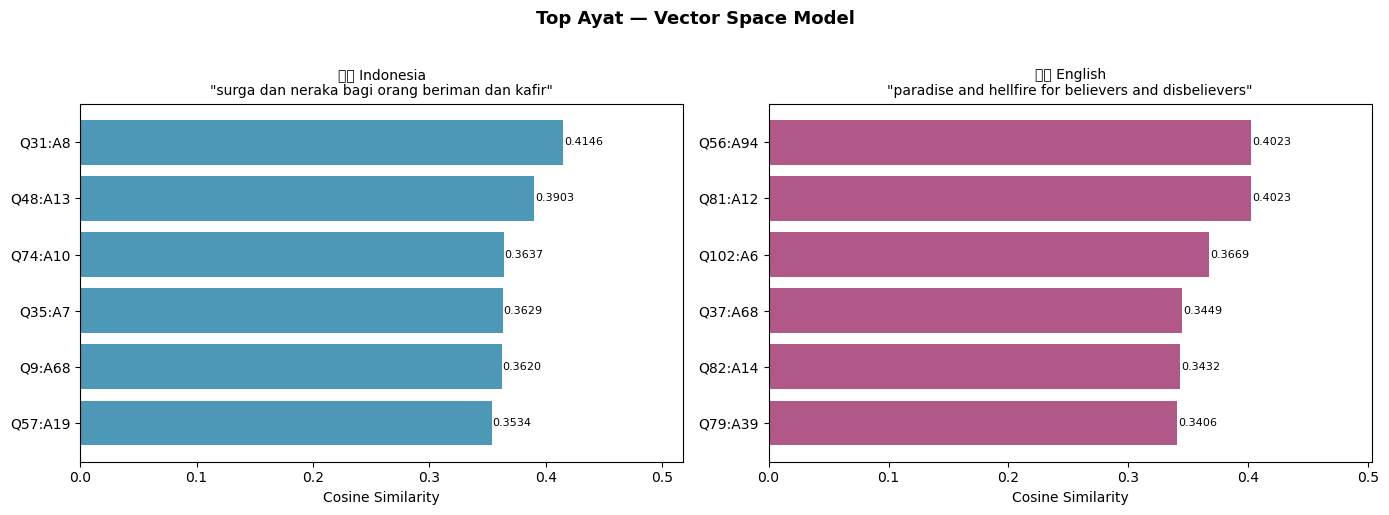

📊 Chart disimpan sebagai 'similarity_comparison.png'


In [13]:
def plot_similarity(queries_per_lang: dict, top_n=8):
    """
    Bar chart side-by-side untuk membandingkan hasil similarity lintas bahasa.
    """
    n_lang = len(queries_per_lang)
    fig, axes = plt.subplots(1, n_lang, figsize=(7 * n_lang, 5))
    if n_lang == 1:
        axes = [axes]

    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

    for ax, (lang, query), color in zip(axes, queries_per_lang.items(), colors):
        hasil = cari_ayat(query, lang=lang, top_n=top_n)
        if hasil.empty:
            ax.text(0.5, 0.5, 'No results', ha='center')
            continue
        label = [f"Q{r['surah']}:A{r['ayat']}" for _, r in hasil.iterrows()]
        skor  = hasil['similarity'].tolist()
        bars  = ax.barh(label[::-1], skor[::-1], color=color, alpha=0.85)
        for bar, val in zip(bars, skor[::-1]):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=8)
        flag = {'Indonesia': '🇮🇩', 'English': '🇬🇧'}.get(lang, '🌐')
        ax.set_title(f'{flag} {lang}\n"{query}"', fontsize=10)
        ax.set_xlabel('Cosine Similarity')
        ax.set_xlim(0, max(skor) * 1.25)

    plt.suptitle('Top Ayat — Vector Space Model', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print("📊 Chart disimpan sebagai 'similarity_comparison.png'")


plot_similarity({
    'Indonesia': 'surga dan neraka bagi orang beriman dan kafir',
    'English'  : 'paradise and hellfire for believers and disbelievers',
}, top_n=6)

## 🔑 8. Analisis TF-IDF — Kata Kunci Sebuah Ayat

In [12]:
def analisis_tfidf_ayat(surah, ayat, lang='Indonesia', top_kata=10):
    """Tampilkan kata-kata dengan bobot TF-IDF tertinggi pada ayat tertentu."""
    df_lang   = corpus[lang]
    vectorizer = models[lang]['vectorizer']
    matrix    = models[lang]['matrix']

    baris = df_lang[(df_lang['surah'] == surah) & (df_lang['ayat'] == ayat)]
    if baris.empty:
        print(f"Ayat {surah}:{ayat} tidak ditemukan di [{lang}]!"); return

    idx    = baris.index[0]
    fitur  = vectorizer.get_feature_names_out()
    bobot  = matrix[idx].toarray()[0]
    df_tf  = pd.DataFrame({'kata': fitur, 'bobot': bobot})
    df_tf  = df_tf[df_tf['bobot'] > 0].sort_values('bobot', ascending=False).head(top_kata)

    flag = {'Indonesia': '🇮🇩', 'English': '🇬🇧'}.get(lang, '🌐')
    print(f"\n{flag} [{lang}] Surah {surah}:{ayat}")
    print(f"   Teks  : {baris['teks'].values[0]}")
    print(f"   Top-{top_kata} TF-IDF:")
    print(df_tf.to_string(index=False))

# Ayat Kursi — tampilkan dalam dua bahasa
analisis_tfidf_ayat(2, 255, lang='Indonesia')
analisis_tfidf_ayat(2, 255, lang='English')


🇮🇩 [Indonesia] Surah 2:255
   Teks  : Allah, tidak ada Tuhan (yang berhak disembah) melainkan Dia Yang Hidup kekal lagi terus menerus mengurus (makhluk-Nya); tidak mengantuk dan tidak tidur. Kepunyaan-Nya apa yang di langit dan di bumi. Tiada yang dapat memberi syafa'at di sisi Allah tanpa izin-Nya? Allah mengetahui apa-apa yang di hadapan mereka dan di belakang mereka, dan mereka tidak mengetahui apa-apa dari ilmu Allah melainkan apa yang dikehendaki-Nya. Kursi Allah meliputi langit dan bumi. Dan Allah tidak merasa berat memelihara keduanya, dan Allah Maha Tinggi lagi Maha Besar.
   Top-10 TF-IDF:
     kata    bobot
mengantuk 0.214199
      apa 0.212228
melainkan 0.187226
 mengurus 0.184350
    tidur 0.184350
      nya 0.179999
  menerus 0.174297
   langit 0.168939
    terus 0.167165
 meliputi 0.163700

🇬🇧 [English] Surah 2:255
   Teks  : Allah - there is no deity except Him, the Ever-Living, the Sustainer of [all] existence. Neither drowsiness overtakes Him nor sleep. To Him belongs